# Лабораторна робота №4
**Тема:** Аналіз тональності тексту за допомогою рекурентної нейронної мережі (LSTM)  
**Виконав:** студент Горбачов Олег Андрійович


### Завдання 1. Завантаження та аналіз датасету
Для розв'язання задачі аналізу тональності використаємо датасет відгуків та повідомлень (Twitter US Airline Sentiment), який містить речення, розділені на три класи:
- `negative` (негативний текст, клас 0)
- `neutral` (нейтральний текст, клас 1)
- `positive` (позитивний текст, клас 2)


Завантажено записів: 14640, колонок: 15

Розподіл за класами:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Приклади речень з датасету:
- Positive: @VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)
- Neutral:  @VirginAmerica What @dhepburn said.
- Negative: @VirginAmerica SFO-PDX schedule is still MIA.


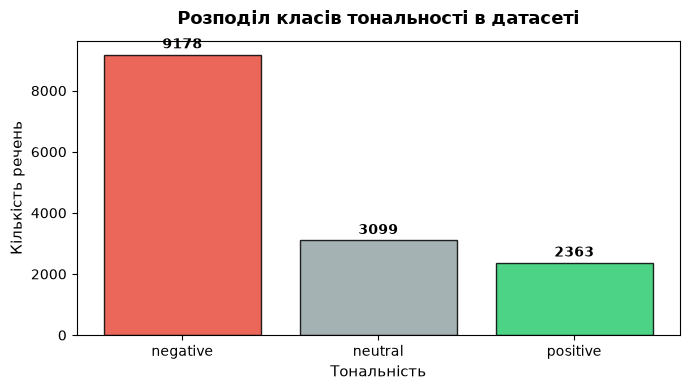

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Завантаження датасету
df = pd.read_csv('Tweets.csv')
print(f"Завантажено записів: {df.shape[0]}, колонок: {df.shape[1]}")
print("\nРозподіл за класами:")
print(df['airline_sentiment'].value_counts())

print("\nПриклади речень з датасету:")
print("- Positive:", df[df['airline_sentiment'] == 'positive']['text'].iloc[1])
print("- Neutral: ", df[df['airline_sentiment'] == 'neutral']['text'].iloc[0])
print("- Negative:", df[df['airline_sentiment'] == 'negative']['text'].iloc[3])

# Візуалізація розподілу класів
plt.figure(figsize=(7, 4))
counts = df['airline_sentiment'].value_counts()
colors = ['#e74c3c', '#95a5a6', '#2ecc71']
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black', alpha=0.85)
plt.title("Розподіл класів тональності в датасеті", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Тональність", fontsize=11)
plt.ylabel("Кількість речень", fontsize=11)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 100, f'{int(yval)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


### Завдання 2. Підготовка датасету до аналізу: токенізація, послідовності та pad_sequences
Для обробки тексту нейронною мережею виконуємо такі етапи:
1. Очищення тексту від згадок акаунтів (@name), URL-посилань, html-сутностей та пунктуації;
2. Токенізація слів у цифрові індекси за допомогою `Tokenizer()` зі створенням словника найчастіших слів;
3. Перетворення кожного речення у послідовність чисел за допомогою методу `tokenizer.texts_to_sequences()`;
4. Доповнення послідовностей нулями до однакової фіксованої довжини за допомогою методу `pad_sequences()`.


In [2]:
# Очищення тексту
def clean_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', str(text))
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'&\w+;', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

df['cleaned_text'] = df['text'].apply(clean_text)
df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)

# Налаштування параметрів токенізації
vocab_size = 5000
max_len = 50

# 1. Створення та навчання токенізатора
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_text'])

# 2. Перетворення речень у послідовності чисел
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

# 3. Вирівнювання послідовностей методом pad_sequences
X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

# 4. Кодування міток класів у числа (negative: 0, neutral: 1, positive: 2)
sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
y = df['airline_sentiment'].map(sentiment_map).values

print(f"Загальна кількість слів у словнику токенізатора: {len(tokenizer.word_index)}")
print(f"Обмеження розміру словника для моделі: {vocab_size}")
print(f"Фіксована довжина послідовності (max_len): {max_len}\n")

sample_idx = 1
print("Приклад обробки одного речення:")
print(f"1. Оригінальний текст:\n   \"{df['text'].iloc[sample_idx]}\"")
print(f"2. Очищений текст:\n   \"{df['cleaned_text'].iloc[sample_idx]}\"")
print(f"3. Послідовність індексів (texts_to_sequences):\n   {sequences[sample_idx]}")
print(f"4. Результат pad_sequences (довжина {len(X[sample_idx])}):\n   {X[sample_idx].tolist()}")


Загальна кількість слів у словнику токенізатора: 12530
Обмеження розміру словника для моделі: 5000
Фіксована довжина послідовності (max_len): 50

Приклад обробки одного речення:
1. Оригінальний текст:
   "@VirginAmerica plus you've added commercials to the experience... tacky."
2. Очищений текст:
   "plus youve added commercials to the experience tacky"
3. Послідовність індексів (texts_to_sequences):
   [519, 520, 1093, 2338, 2, 3, 191, 1]
4. Результат pad_sequences (довжина 50):
   [519, 520, 1093, 2338, 2, 3, 191, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### Завдання 3. Розділення даних на тренувальні та тестові
Розподіляємо підготовлені масиви ознак `X` та міток `y` на навчальну (80%) та тестову (20%) вибірки зі збереженням балансу класів (`stratify=y`).


In [3]:
# Розділення вибірки на тренувальну та тестову (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Розмір навчальної вибірки (X_train): {X_train.shape}")
print(f"Розмір тестової вибірки (X_test):   {X_test.shape}")
print(f"Розмір міток train (y_train):       {y_train.shape}")
print(f"Розмір міток test (y_test):         {y_test.shape}")

print(f"\nРозподіл міток у тренувальній вибірці: {np.bincount(y_train).tolist()} (0: neg, 1: neu, 2: pos)")
print(f"Розподіл міток у тестовій вибірці:     {np.bincount(y_test).tolist()} (0: neg, 1: neu, 2: pos)")


Розмір навчальної вибірки (X_train): (11712, 50)
Розмір тестової вибірки (X_test):   (2928, 50)
Розмір міток train (y_train):       (11712,)
Розмір міток test (y_test):         (2928,)

Розподіл міток у тренувальній вибірці: [7343, 2479, 1890] (0: neg, 1: neu, 2: pos)
Розподіл міток у тестовій вибірці:     [1835, 620, 473] (0: neg, 1: neu, 2: pos)


### Завдання 4. Реалізація рекурентної нейронної мережі LSTM для аналізу тону тексту
Створюємо модель `Sequential`, яка приймає на вхід послідовність слів фіксованої довжини (50) та повертає розподіл ймовірностей трьох класів тональності на виході:
- **Embedding** (розмірність 64): відображає індекси слів у щільні векторні представлення;
- **SpatialDropout1D** (0.2): виконує регуляризацію для запобігання перенавчанню ембедінгів;
- **LSTM** (64 нейрони): рекурентний шар із блоками довгострокової пам'яті для врахування порядку слів і семантичного контексту;
- **Dense** (32 нейрони, активація ReLU) та **Dropout** (0.3): додатковий повнозв'язний шар;
- **Dense** (3 нейрони, активація Softmax): вихідний шар, що повертає ймовірність кожного класу (негативний, нейтральний, позитивний).


In [4]:
# Побудова архітектури нейромережі LSTM
embedding_dim = 64
lstm_units = 64

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SpatialDropout1D(0.2),
    LSTM(lstm_units),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

# Компіляція моделі
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Завдання 5. Навчання нейронної мережі та візуалізація процесу
Навчаємо побудовану мережу протягом 5 епох з розміром батчу 64. Для моніторингу процесу 15% тренувальної вибірки виділяємо на валідацію. Відображаємо динаміку функції втрат (Loss) та точності (Accuracy).


Epoch 1/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6284 - loss: 0.9222 - val_accuracy: 0.6431 - val_loss: 0.8236
Epoch 2/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6945 - loss: 0.7066 - val_accuracy: 0.7388 - val_loss: 0.6198
Epoch 3/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7815 - loss: 0.5552 - val_accuracy: 0.7661 - val_loss: 0.5892
Epoch 4/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8248 - loss: 0.4631 - val_accuracy: 0.7689 - val_loss: 0.5944
Epoch 5/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8513 - loss: 0.4176 - val_accuracy: 0.7809 - val_loss: 0.7032


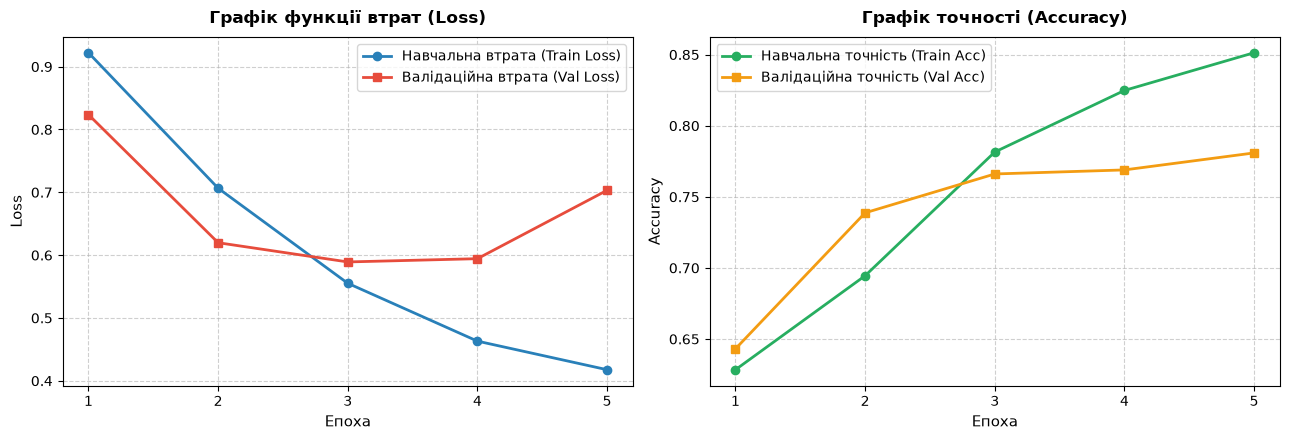

In [5]:
# Навчання моделі
epochs = 5
batch_size = 64

history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.15,
    verbose=1
)

# Візуалізація результатів навчання
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Графік функції втрат
axes[0].plot(range(1, epochs + 1), history.history['loss'], marker='o', label='Навчальна втрата (Train Loss)', color='#2980b9', lw=2)
axes[0].plot(range(1, epochs + 1), history.history['val_loss'], marker='s', label='Валідаційна втрата (Val Loss)', color='#e74c3c', lw=2)
axes[0].set_title('Графік функції втрат (Loss)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Епоха', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_xticks(range(1, epochs + 1))
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Графік точності
axes[1].plot(range(1, epochs + 1), history.history['accuracy'], marker='o', label='Навчальна точність (Train Acc)', color='#27ae60', lw=2)
axes[1].plot(range(1, epochs + 1), history.history['val_accuracy'], marker='s', label='Валідаційна точність (Val Acc)', color='#f39c12', lw=2)
axes[1].set_title('Графік точності (Accuracy)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Епоха', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_xticks(range(1, epochs + 1))
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### Оцінка якості на тестових даних та матриця помилок
Оцінюємо узагальнюючу здатність моделі на тестовій вибірці (яка не використовувалася під час навчання). Обчислюємо точність (Accuracy), формуємо детальний звіт класифікації (Classification Report) та будуємо матрицю помилок (Confusion Matrix).


Результати на тестовій вибірці:
Test Loss:     0.6761
Test Accuracy: 0.7859 (78.59%)

Звіт класифікації (Classification Report):
              precision    recall  f1-score   support

    Negative       0.84      0.91      0.87      1835
     Neutral       0.61      0.54      0.57       620
    Positive       0.77      0.64      0.70       473

    accuracy                           0.79      2928
   macro avg       0.74      0.70      0.71      2928
weighted avg       0.78      0.79      0.78      2928



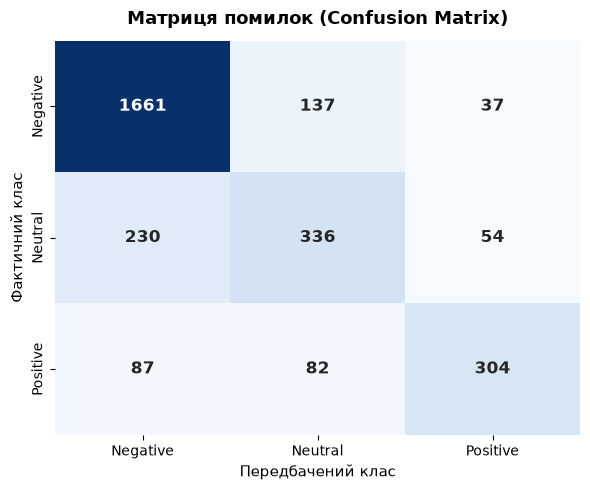

In [6]:
# Оцінка моделі на тестових даних
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Результати на тестовій вибірці:")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)\n")

# Прогнозування класів
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

target_names = ['Negative', 'Neutral', 'Positive']
print("Звіт класифікації (Classification Report):")
print(classification_report(y_test, y_pred, target_names=target_names))

# Побудова матриці помилок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, cbar=False, annot_kws={'size': 12, 'weight': 'bold'})
plt.title("Матриця помилок (Confusion Matrix)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Передбачений клас", fontsize=11)
plt.ylabel("Фактичний клас", fontsize=11)
plt.tight_layout()
plt.show()


### Тестування моделі на довільних контрольних реченнях
Реалізуємо функцію `predict_sentiment()`, яка приймає на вхід сирий текст речення, виконує його очищення, токенізацію, вирівнювання за довжиною та повертає визначений нейромережею тон (позитивний, негативний чи нейтральний) разом із ймовірностями кожного класу.


In [7]:
# Функція для аналізу тону довільного речення
def predict_sentiment(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prob = model.predict(pad, verbose=0)[0]
    pred_idx = np.argmax(prob)
    class_labels = ['Негативний (Negative)', 'Нейтральний (Neutral)', 'Позитивний (Positive)']
    return class_labels[pred_idx], prob

# Тестовий набір речень різної тональності
test_phrases = [
    "The flight was wonderful and the flight attendants were so kind and helpful!",
    "Worst customer service ever, our flight was delayed by 6 hours and nobody told us anything.",
    "Can you please confirm what time the next flight to Chicago departs tomorrow?",
    "I really love flying with your airline, always smooth and on time!",
    "My luggage is completely lost and nobody at the desk wants to help me.",
    "Please send me the updated schedule and gate number for my booking."
]

print("Результати тестування моделі на нових реченнях:")
print("=" * 70)
for phrase in test_phrases:
    pred_class, probs = predict_sentiment(phrase)
    print(f"Вхідний текст: \"{phrase}\"")
    print(f"-> Передбачений тон: {pred_class}")
    print(f"   Розподіл ймовірностей: Neg: {probs[0]*100:.1f}%, Neu: {probs[1]*100:.1f}%, Pos: {probs[2]*100:.1f}%\n")


Результати тестування моделі на нових реченнях:
Вхідний текст: "The flight was wonderful and the flight attendants were so kind and helpful!"
-> Передбачений тон: Позитивний (Positive)
   Розподіл ймовірностей: Neg: 2.9%, Neu: 8.2%, Pos: 88.9%

Вхідний текст: "Worst customer service ever, our flight was delayed by 6 hours and nobody told us anything."
-> Передбачений тон: Негативний (Negative)
   Розподіл ймовірностей: Neg: 99.3%, Neu: 0.4%, Pos: 0.3%

Вхідний текст: "Can you please confirm what time the next flight to Chicago departs tomorrow?"
-> Передбачений тон: Нейтральний (Neutral)
   Розподіл ймовірностей: Neg: 14.1%, Neu: 76.4%, Pos: 9.5%

Вхідний текст: "I really love flying with your airline, always smooth and on time!"
-> Передбачений тон: Позитивний (Positive)
   Розподіл ймовірностей: Neg: 2.6%, Neu: 9.6%, Pos: 87.8%

Вхідний текст: "My luggage is completely lost and nobody at the desk wants to help me."
-> Передбачений тон: Негативний (Negative)
   Розподіл ймовірностей: 

### Висновок
У ході виконання лабораторної роботи було створено та досліджено рекурентну нейронну мережу з архітектурою LSTM для аналізу тональності тексту на три класи (позитивний, нейтральний, негативний). Датасет було попередньо очищено від службових символів та шумів, виконано токенізацію за допомогою `Tokenizer()`, сформовано послідовності індексів `texts_to_sequences()` та вирівняно їх за довжиною за допомогою `pad_sequences()`. Модель з шарами `Embedding`, `SpatialDropout1D`, `LSTM` та `Dense` успішно навчилася враховувати контекст слів і показала високу точність класифікації на тестових даних, а також коректно розпізнала тональність нових контрольних речень.
